In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import dataframe_image as dfi
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Dataset With All Outliers Removed

First load dataset and look at the first 5 rows.

In [4]:
df = pd.read_csv("weather_classification_data.csv")
df['Was_Rain'] = 0
df.loc[df['Weather Type'] == 'Rainy' , 'Was_Rain'] = 1
df.head()

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type,Was_Rain
0,14.0,73,9.5,82.0,partly cloudy,1010.82,2,Winter,3.5,inland,Rainy,1
1,39.0,96,8.5,71.0,partly cloudy,1011.43,7,Spring,10.0,inland,Cloudy,0
2,30.0,64,7.0,16.0,clear,1018.72,5,Spring,5.5,mountain,Sunny,0
3,38.0,83,1.5,82.0,clear,1026.25,7,Spring,1.0,coastal,Sunny,0
4,27.0,74,17.0,66.0,overcast,990.67,1,Winter,2.5,mountain,Rainy,1


In [5]:
df = df[ (df["Temperature"] >= -20) &
    (df["Temperature"] <= 55) & (df["Atmospheric Pressure"] <= 1085) & (df["Atmospheric Pressure"] >= 870)]

In [6]:
df = df[ df['Humidity'] <= 100]

In [7]:
df = df[df['Precipitation (%)'] <= 100]

In [8]:
print(df.dtypes) 

numerical = df.select_dtypes(include='number').columns.tolist()

Temperature             float64
Humidity                  int64
Wind Speed              float64
Precipitation (%)       float64
Cloud Cover              object
Atmospheric Pressure    float64
UV Index                  int64
Season                   object
Visibility (km)         float64
Location                 object
Weather Type             object
Was_Rain                  int64
dtype: object


In [9]:
df.describe() 


,Temperature,Humidity,Wind Speed,Precipitation (%),Atmospheric Pressure,UV Index,Visibility (km),Was_Rain
count,11750.000000,11750.000000,11750.000000,11750.000000,11750.000000,11750.000000,11750.000000,11750.000000
mean,18.224426,67.703149,9.394213,50.601957,1004.551123,3.623234,5.333787,0.250468
std,15.361547,19.096377,6.336468,31.147812,19.954450,3.605576,3.060403,0.433301
min,-20.000000,20.000000,0.000000,0.000000,870.050000,0.000000,0.000000,0.000000
25%,4.000000,57.000000,5.000000,18.000000,994.912500,1.000000,3.000000,0.000000
50%,21.000000,69.000000,8.500000,54.000000,1007.230000,2.000000,5.000000,0.000000
75%,30.000000,82.000000,13.000000,79.000000,1016.210000,6.000000,7.500000,1.000000
max,55.000000,100.000000,48.500000,100.000000,1084.820000,14.000000,20.000000,1.000000


In [10]:
df[numerical].median()

Temperature               21.00
Humidity                  69.00
Wind Speed                 8.50
Precipitation (%)         54.00
Atmospheric Pressure    1007.23
UV Index                   2.00
Visibility (km)            5.00
Was_Rain                   0.00
dtype: float64

In [12]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 11750 entries, 0 to 13199
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Temperature           11750 non-null  float64
 1   Humidity              11750 non-null  int64  
 2   Wind Speed            11750 non-null  float64
 3   Precipitation (%)     11750 non-null  float64
 4   Cloud Cover           11750 non-null  object 
 5   Atmospheric Pressure  11750 non-null  float64
 6   UV Index              11750 non-null  int64  
 7   Season                11750 non-null  object 
 8   Visibility (km)       11750 non-null  float64
 9   Location              11750 non-null  object 
 10  Weather Type          11750 non-null  object 
 11  Was_Rain              11750 non-null  int64  
dtypes: float64(5), int64(3), object(4)
memory usage: 1.2+ MB


Temperature             0
Humidity                0
Wind Speed              0
Precipitation (%)       0
Cloud Cover             0
Atmospheric Pressure    0
UV Index                0
Season                  0
Visibility (km)         0
Location                0
Weather Type            0
Was_Rain                0
dtype: int64

There are no missing values in this data.

Next look to see what the balance of classes are for the target variable.

<Axes: ylabel='count'>

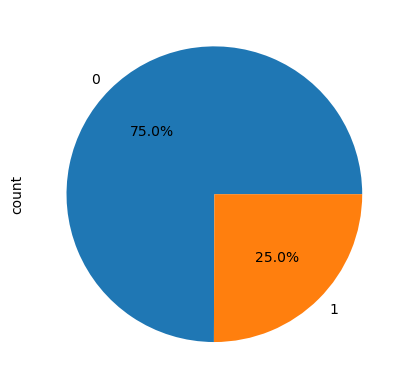

In [15]:
target_counts = df['Was_Rain'].value_counts()
target_counts.plot(kind="pie",autopct="%1.1f%%")

Next check there are no spelling errors in categorical variables.

In [17]:
for i in ['Cloud Cover', 'Season' , 'Location' , 'Weather Type']:
    print(i,':' , df[i].unique())

Cloud Cover : ['partly cloudy' 'clear' 'overcast' 'cloudy']
Season : ['Winter' 'Spring' 'Summer' 'Autumn']
Location : ['inland' 'mountain' 'coastal']
Weather Type : ['Rainy' 'Cloudy' 'Sunny' 'Snowy']


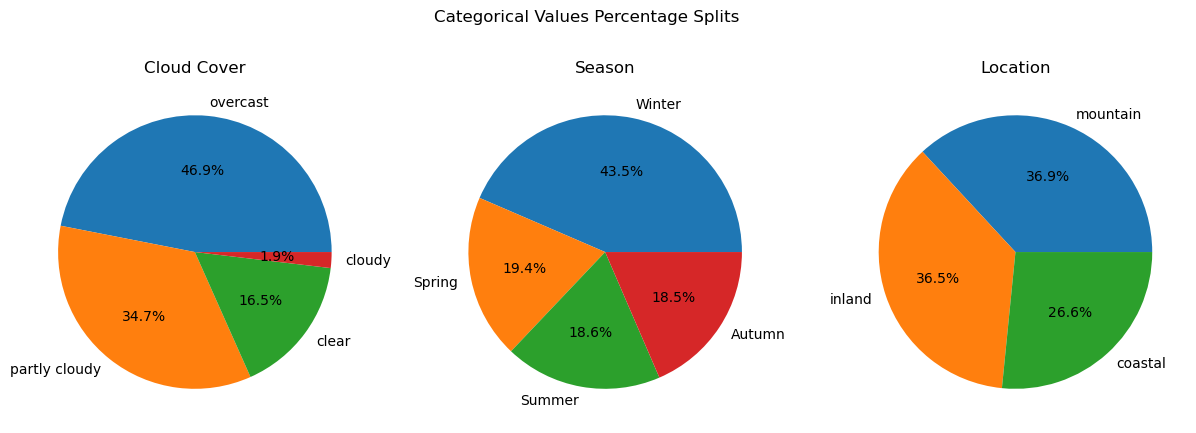

In [18]:
fig, ax = plt.subplots(1, 3,figsize=(15,5))
cloud_counts = df['Cloud Cover'].value_counts()
season_counts = df['Season'].value_counts()
location_counts = df['Location'].value_counts()
fig.suptitle("Categorical Values Percentage Splits")
ax1 = cloud_counts.plot(kind="pie",autopct="%1.1f%%", ax = ax [0])
ax1.set_ylabel("")
ax1.set_title("Cloud Cover")
ax2 = season_counts.plot(kind="pie", autopct="%1.1f%%",ax = ax [1])
ax2.set_ylabel("")
ax2.set_title("Season")
ax3 = location_counts.plot(kind = 'pie' , autopct="%1.1f%%", ax = ax[2])
ax3.set_ylabel("")
ax3.set_title("Location")
plt.show()

## Dealing with Categorical Variables

In [20]:
df["Cloud Cover"] = pd.Categorical(
    df["Cloud Cover"],
    categories=["clear", "partly cloudy", "cloudy", "overcast"],
    ordered=True
)

df["cloud_cover"] = df["Cloud Cover"].cat.codes
df.drop(columns = ["Cloud Cover", "Weather Type"] , inplace = True)

Used Ordinal Coding as Cloud Cover has an ordered ranking of amount of cloud. 

In [22]:
df = pd.get_dummies(df, columns=["Season", "Location"], dtype=int, drop_first = True)

Location and Season have no specific order so used one-hot encoding which makes new binary columns for each unique variable in the data. 

In [24]:
df.head()

,Temperature,Humidity,Wind Speed,Precipitation (%),Atmospheric Pressure,UV Index,Visibility (km),Was_Rain,cloud_cover,Season_Spring,Season_Summer,Season_Winter,Location_inland,Location_mountain
0,14.0,73,9.5,82.0,1010.82,2,3.5,1,1,0,0,1,1,0
1,39.0,96,8.5,71.0,1011.43,7,10.0,0,1,1,0,0,1,0
2,30.0,64,7.0,16.0,1018.72,5,5.5,0,0,1,0,0,0,1
3,38.0,83,1.5,82.0,1026.25,7,1.0,0,0,1,0,0,0,0
4,27.0,74,17.0,66.0,990.67,1,2.5,1,3,0,0,1,0,1


## Outlier Exploration

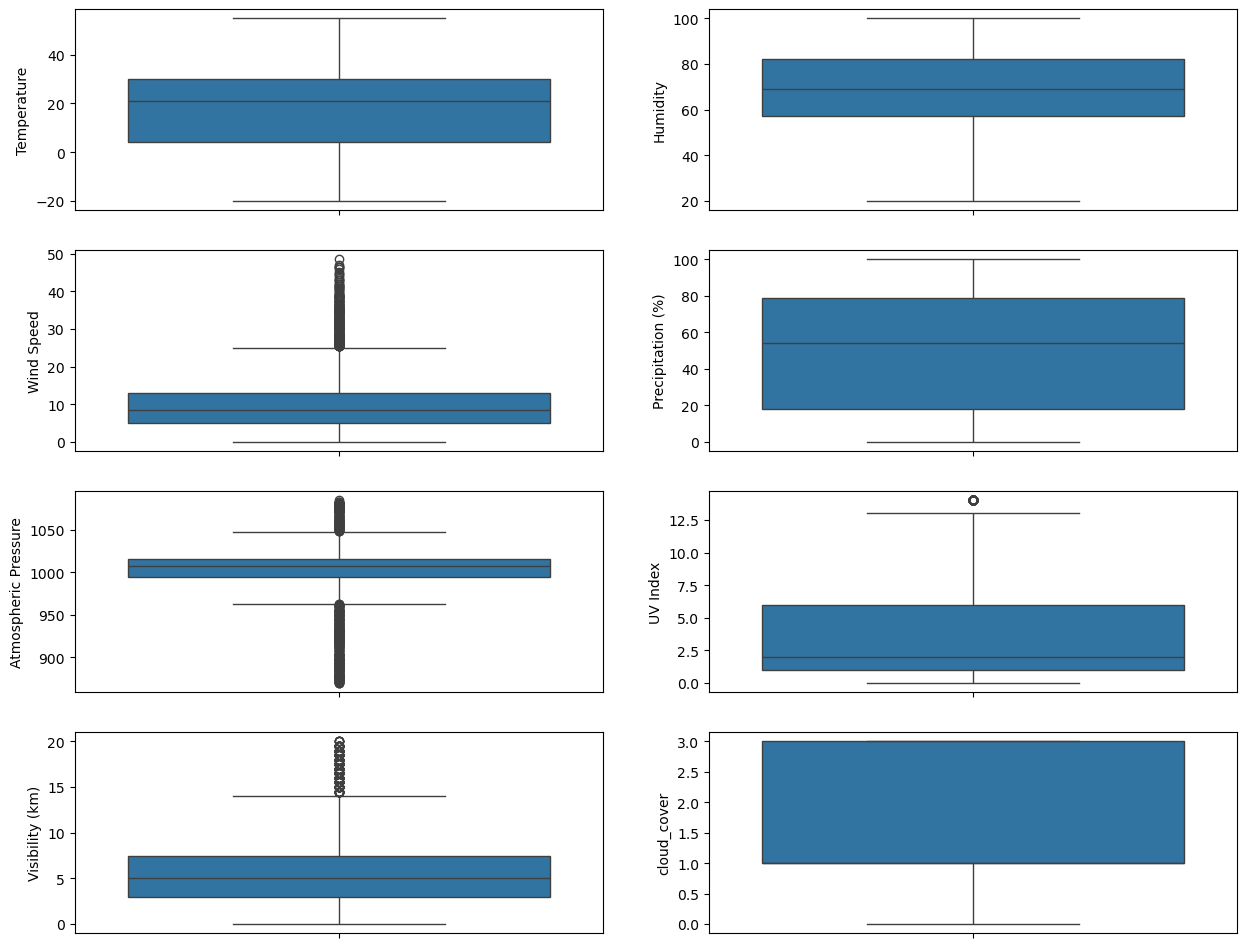

In [26]:
fig, ax = plt.subplots(4, 2,figsize=(15,12))
ax1 = sns.boxplot(y = "Temperature", data = df,  ax = ax[0,0])
ax1.set_ylabel("Temperature")
ax2 = sns.boxplot(y = "Humidity" , data = df,  ax = ax[0,1])
ax3 = sns.boxplot(y = "Wind Speed" , data = df,  ax = ax[1,0])
ax4 = sns.boxplot(y = "Precipitation (%)" , data = df,  ax = ax[1,1])
ax5 = sns.boxplot(y = "Atmospheric Pressure" , data = df,  ax = ax[2,0])
ax6 = sns.boxplot(y = "UV Index" , data = df,  ax = ax[2,1])
ax7 = sns.boxplot(y = "Visibility (km)" , data = df,  ax = ax[3,0])
ax8 = sns.boxplot(y = "cloud_cover" , data = df,  ax = ax[3,1])

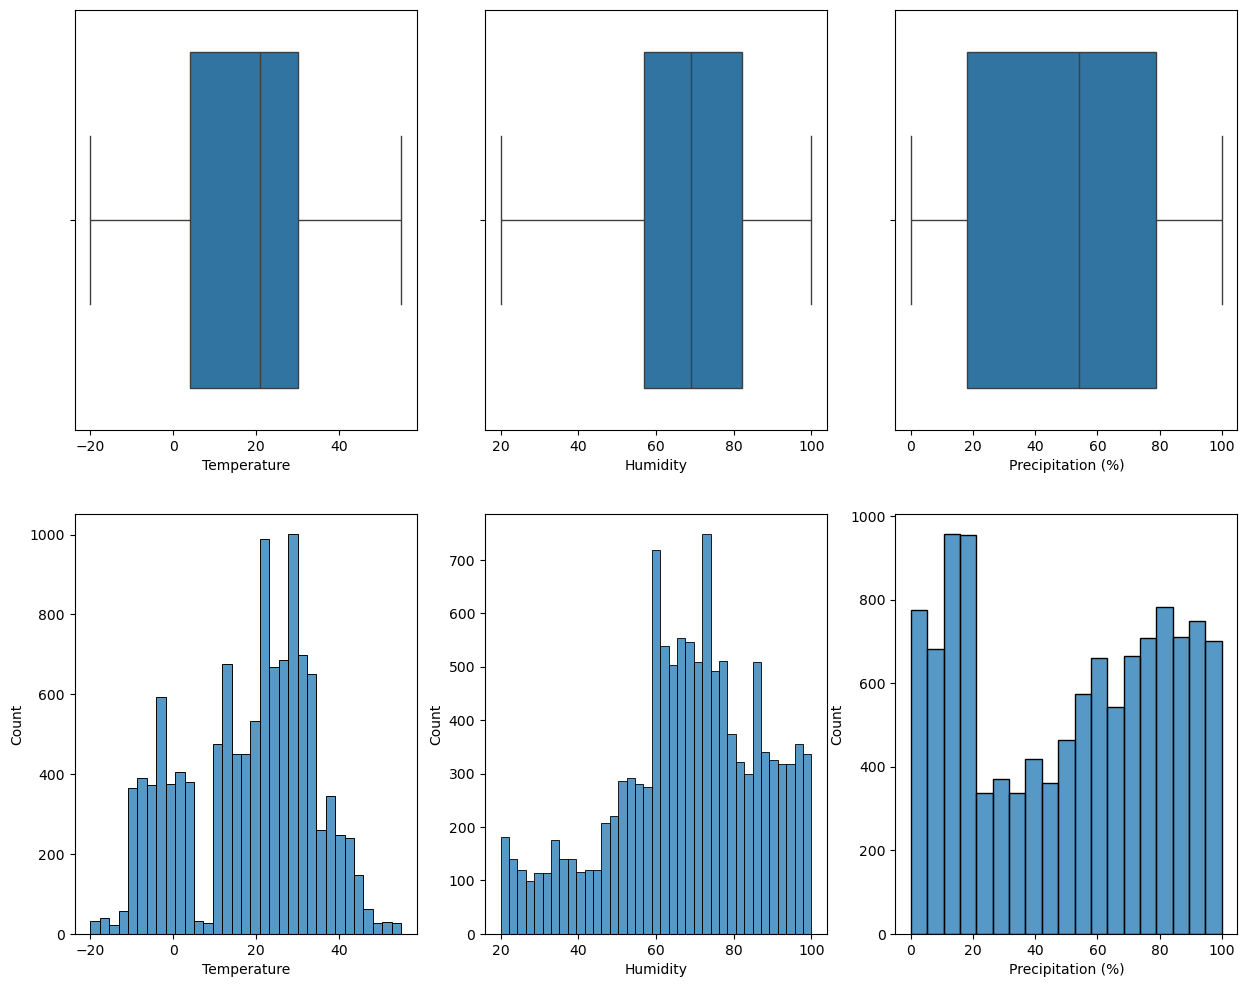

In [27]:
fig, ax = plt.subplots(2, 3,figsize=(15,12))
ax1 = sns.boxplot(x = "Temperature", data = df,  ax = ax[0,0])
ax2 = sns.boxplot(x = "Humidity" , data = df,  ax = ax[0,1])
ax4 = sns.boxplot(x = "Precipitation (%)" , data = df,  ax = ax[0,2])
ax5 = sns.histplot(x = "Temperature" , data = df,  ax = ax[1,0])
ax6 = sns.histplot(x = "Humidity" , data = df,  ax = ax[1,1])
ax7 = sns.histplot(x = "Precipitation (%)" , data = df,  ax = ax[1,2])

In [28]:
 df["Humidity"].skew()

-0.5052757981780222

In [29]:
 df["Precipitation (%)"].skew()
    

-0.09409435185360707

In [30]:
df["UV Index"].skew()

1.0171472324142241

Temperature, Wind Speed, Pressure and Visibility are showing outliers. First investigate Temperature outliers.

<Axes: xlabel='Temperature', ylabel='Count'>

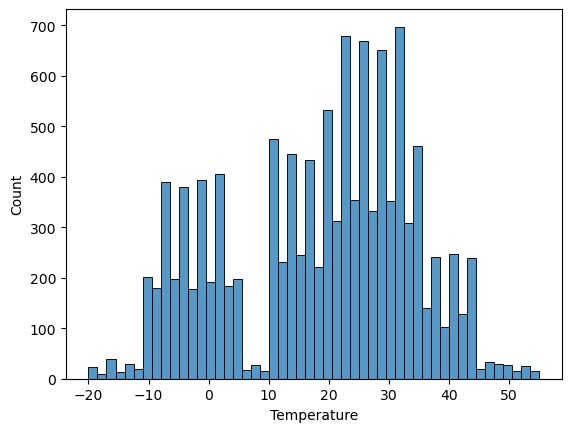

In [32]:
sns.histplot(data = df, x = 'Temperature', bins = 50)

In [33]:
df['Temperature'].skew()

-0.3183945315686424

Left Skewed

<Axes: xlabel='Wind Speed', ylabel='Count'>

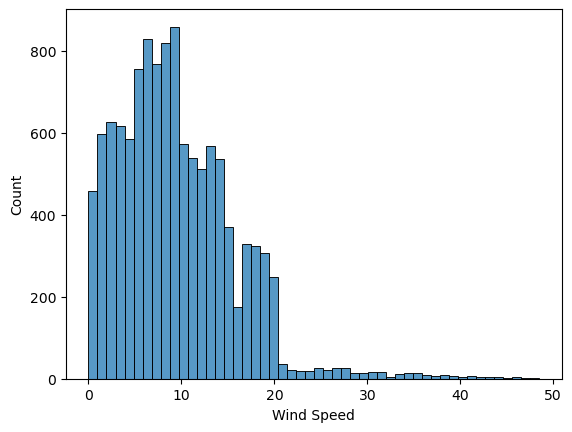

In [36]:
sns.histplot(data = df, x = 'Wind Speed', bins = 50)

In [37]:
df["Wind Speed"].skew()

1.2171962707064454

Looks right skewed.

In [39]:
len_b = len(df)
Q1 = df["Wind Speed"].quantile(0.25)
Q3 = df["Wind Speed"].quantile(0.75)
IQR = Q3 - Q1
len_a = len(df[ (df["Wind Speed"] >= Q1 - (1.5 * IQR)) &
    (df["Wind Speed"] <= Q3 + (1.5 * IQR))])
print(len_b , len_a )
print((100 * (len_b - len_a) / len_b) , '%')

11750 11510
2.0425531914893615 %


2% of the data are outliers. 

<Axes: xlabel='Visibility (km)', ylabel='Count'>

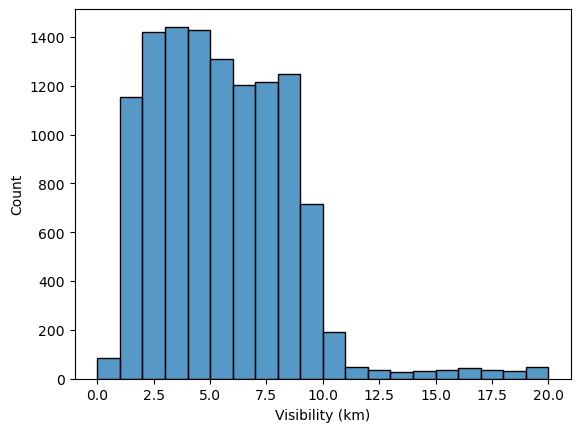

In [41]:
sns.histplot(data = df, x = 'Visibility (km)', bins = 20)

In [42]:
len_b = len(df)
Q1 = df["Visibility (km)"].quantile(0.25)
Q3 = df["Visibility (km)"].quantile(0.75)
IQR = Q3 - Q1
len_a = len(df[ (df["Visibility (km)"] >= Q1 - (1.5 * IQR)) &
    (df["Visibility (km)"] <= Q3 + (1.5 * IQR))])
print(len_b , len_a )
print((100 * (len_b - len_a) / len_b) , '%')

11750 11539
1.7957446808510638 %


In [43]:
df["Visibility (km)"].skew()

1.1009656135586439

1.8% are outliers

<Axes: xlabel='Atmospheric Pressure', ylabel='Count'>

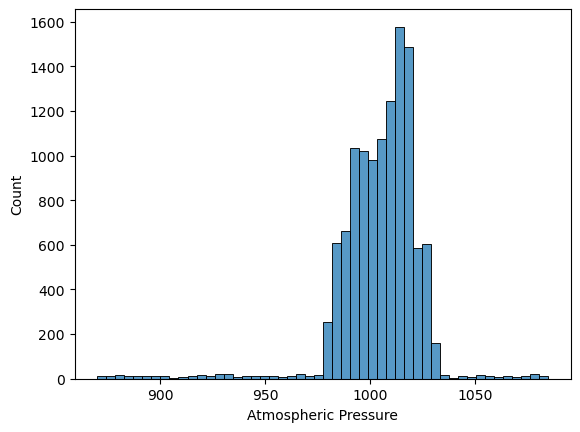

In [45]:
sns.histplot(data = df, x = 'Atmospheric Pressure', bins = 50)

In [46]:
len_b = len(df)
Q1 = df['Atmospheric Pressure'].quantile(0.25)
Q3 = df['Atmospheric Pressure'].quantile(0.75)
IQR = Q3 - Q1
len_a = len(df[ (df['Atmospheric Pressure'] >= Q1 - (1.5 * IQR)) &
    (df['Atmospheric Pressure'] <= Q3 + (1.5 * IQR))])
print(len_b , len_a )
print((100 * (len_b - len_a) / len_b) , '%')

11750 11381
3.1404255319148935 %


In [47]:
df['Atmospheric Pressure'].skew()

-2.1762777339183774

3.14% are outliers

In [49]:
df.describe()

,Temperature,Humidity,Wind Speed,Precipitation (%),Atmospheric Pressure,UV Index,Visibility (km),Was_Rain,cloud_cover,Season_Spring,Season_Summer,Season_Winter,Location_inland,Location_mountain
count,11750.000000,11750.000000,11750.000000,11750.000000,11750.000000,11750.000000,11750.000000,11750.000000,11750.000000,11750.000000,11750.000000,11750.000000,11750.000000,11750.000000
mean,18.224426,67.703149,9.394213,50.601957,1004.551123,3.623234,5.333787,0.250468,1.792511,0.193957,0.185702,0.435234,0.365277,0.368936
std,15.361547,19.096377,6.336468,31.147812,19.954450,3.605576,3.060403,0.433301,1.196718,0.395413,0.388883,0.495809,0.481528,0.482537
min,-20.000000,20.000000,0.000000,0.000000,870.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.000000,57.000000,5.000000,18.000000,994.912500,1.000000,3.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,21.000000,69.000000,8.500000,54.000000,1007.230000,2.000000,5.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,30.000000,82.000000,13.000000,79.000000,1016.210000,6.000000,7.500000,1.000000,3.000000,0.000000,0.000000,1.000000,1.000000,1.000000
max,55.000000,100.000000,48.500000,100.000000,1084.820000,14.000000,20.000000,1.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## Correlation

In [51]:
weathercorr = df.corr(method = 'pearson')
weathercorr

,Temperature,Humidity,Wind Speed,Precipitation (%),Atmospheric Pressure,UV Index,Visibility (km),Was_Rain,cloud_cover,Season_Spring,Season_Summer,Season_Winter,Location_inland,Location_mountain
Temperature,1.000000,-0.383212,-0.150123,-0.471898,0.441622,0.448314,0.361111,0.143901,-0.460680,0.209325,0.215544,-0.502673,-0.119359,-0.114834
Humidity,-0.383212,1.000000,0.384793,0.651169,-0.237166,-0.486471,-0.527462,0.328879,0.482389,-0.103459,-0.101664,0.247130,0.060628,0.045683
Wind Speed,-0.150123,0.384793,1.000000,0.440787,-0.139110,-0.161475,-0.333789,0.343506,0.277045,-0.042800,-0.025359,0.076128,0.023573,0.000030
Precipitation (%),-0.471898,0.651169,0.440787,1.000000,-0.395449,-0.454621,-0.547126,0.438090,0.547992,-0.126195,-0.121952,0.293339,0.064945,0.060449
Atmospheric Pressure,0.441622,-0.237166,-0.139110,-0.395449,1.000000,0.256732,0.182507,-0.027211,-0.348238,0.106599,0.109292,-0.266847,-0.060601,-0.060567
UV Index,0.448314,-0.486471,-0.161475,-0.454621,0.256732,1.000000,0.448524,-0.231712,-0.518343,0.111081,0.114855,-0.272014,-0.057746,-0.058789
Visibility (km),0.361111,-0.527462,-0.333789,-0.547126,0.182507,0.448524,1.000000,-0.367093,-0.400540,0.124795,0.111291,-0.284305,-0.062152,-0.048959
Was_Rain,0.143901,0.328879,0.343506,0.438090,-0.027211,-0.231712,-0.367093,1.000000,0.279474,0.088020,0.091668,-0.203199,-0.053443,-0.073184
cloud_cover,-0.460680,0.482389,0.277045,0.547992,-0.348238,-0.518343,-0.400540,0.279474,1.000000,-0.097513,-0.104111,0.252052,0.057536,0.050919
Season_Spring,0.209325,-0.103459,-0.042800,-0.126195,0.106599,0.111081,0.124795,0.088020,-0.097513,1.000000,-0.234256,-0.430627,-0.035076,-0.043630


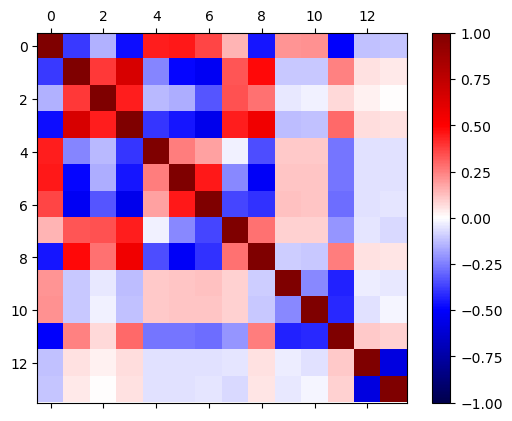

In [52]:
corFig = plt.figure()
figAxis = corFig.add_subplot(111)
corAx = figAxis.matshow(weathercorr, vmin = -1,  vmax = 1, cmap = 'seismic')
corFig.colorbar(corAx)
plt.show()

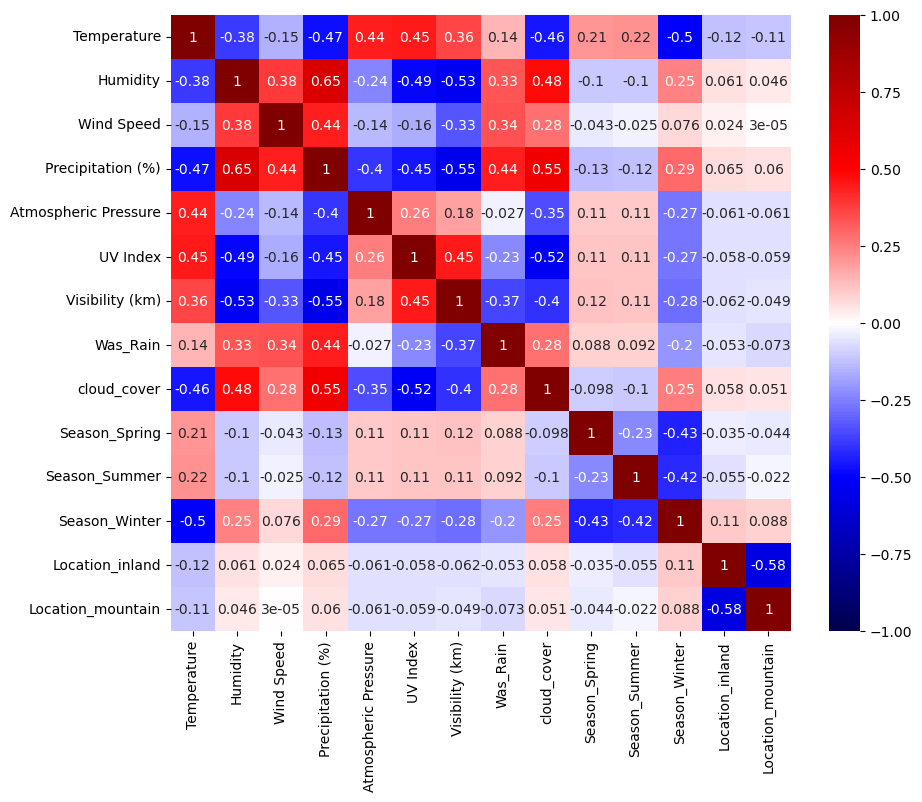

In [107]:
plt.figure(figsize = (10,8))
sns.heatmap(weathercorr, vmin=-1, vmax=1, annot = True, cmap = 'seismic')
plt.show()

In [119]:
# Define the predictor variables
X = df.drop(columns=['Was_Rain'])

# Add a constant to the model 
X = add_constant(X)

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data['Feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data[1:])

                 Feature       VIF
1            Temperature  1.905820
2               Humidity  2.036986
3             Wind Speed  1.311369
4      Precipitation (%)  2.459511
5   Atmospheric Pressure  1.352251
6               UV Index  1.672264
7        Visibility (km)  1.667885
8            cloud_cover  1.751777
9          Season_Spring  1.651691
10         Season_Summer  1.632151
11         Season_Winter  2.282657
12       Location_inland  1.606690
13     Location_mountain  1.603117
